# TOPIC MODELLING

## Hypotheses

### Axis 1: Topic Discovery 

#### LDA vs BERTopic

### LDA TOPIC MODELLING

* Split the data as a train test split and train the model on train data and test the model in test data.
* Preprocess the train data with the pipeline created and create a bow and tfidf vectors.
* Train multiple LDA models with topic counts ranging from 5 to 10 (aligned with ground truth: 5 ticket types and 9 ticket subjects).
* Evaluate all models on test data and select the best one based on coherence score.
* For final test validation, use the 5-topic model (matching the number of ticket types).   
* Visualize the topics
* Save all trained models and evaluation artifacts.

In [22]:
# Import the necessary modules 
import numpy as np
import pandas as pd 
import sys
import os
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from gensim.models.coherencemodel import CoherenceModel
from gensim import corpora as gensim_corpora

In [2]:
# This 'goes up' two levels from your current subfolder to reach the project root
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if root_path not in sys.path:
    sys.path.insert(0, root_path)

# Verify 'src' is now visible
print(f"Project Root: {root_path}")
print(f"Is 'src' folder accessible? {os.path.exists(os.path.join(root_path, 'src'))}")
print(f"Is 'data' folder accessible? {os.path.exists(os.path.join(root_path, 'data'))}")

Project Root: D:\MSc Data Science\TB 2\IATA\CW\EMATM0067_2025_TB-2-g43
Is 'src' folder accessible? True
Is 'data' folder accessible? True


In [3]:
from src.features.TopicModelling import initialize_ldaModel, bert_topicModel
from src.evaluation.TopicModel_Visualization import plot_topicModel_heatmap, plot_topicModel_histogram
from src.pipeline.Preprocessing import to_lower, expand_contractions, replace_product_purchased, remove_noise, tokenize_text, remove_stopwords_all, filter_short_tokens, lemmatize_tokens
from src.features.Embeddings import vectorize_boa, vectorize_tfidf, bow_vectorizer, tfidf_vectorizer

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Thiruvel A P\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [5]:
# train test split 
X_train, X_test = train_test_split(
                    df,
                    test_size=0.2,
                    random_state=42
                  )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (6775, 17)
X_test shape: (1694, 17)


In [6]:
# Preprocess the text to store the tokens embeddings 
def preprocess_text(text_description: pd.Series):
    text = text_description.copy()
    text = text.apply(to_lower)
    text = text.apply(expand_contractions)
    text = text.apply(replace_product_purchased)
    text = text.apply(remove_noise)
    tokens = text.apply(tokenize_text)
    tokens = tokens.apply(remove_stopwords_all)
    tokens = tokens.apply(filter_short_tokens)
    tokens = tokens.apply(lemmatize_tokens)
    return tokens

In [7]:
# Processing pipeline of train data
# FIX: pass only the text column (pd.Series) — not the whole DataFrame
trained_tokens = preprocess_text(X_train['Ticket Description'])

len(trained_tokens)

6775

In [8]:
# Build the Bag of words vectors, tf-idf vectors, skipgram embeddings and sbert embeddings 
def build_all_representations(tokens):
    clean_text = tokens.apply(lambda t: ' '.join(t))
    print("Building BoW...", end=" ")
    X_bow = vectorize_boa(clean_text)
    print(f"shape: {X_bow.shape}")
    print("Building TF-IDF...", end=" ")
    X_tfidf = vectorize_tfidf(clean_text)
    print(f"shape: {X_tfidf.shape}")
    return X_bow, X_tfidf

In [9]:
# train data BoW and TFIDF
trained_bow, trained_tfidf = build_all_representations(trained_tokens)

Building BoW... shape: (6775, 5000)
Building TF-IDF... shape: (6775, 2994)


In [10]:
# LDA models on BoW — train for num_topics in range(5, 11)
# Ground truth: 5 ticket types and 9 ticket subjects → sweep 5 to 10
# Stored as: lda_dict_bow[n_topics] = (model, gensim_dict)
lda_dict_bow = {}
for n_topics in range(5, 11):
    ldaModel_bow, lda_bow_dict = initialize_ldaModel(trained_bow, bow_vectorizer, num_topics=n_topics)
    lda_dict_bow[n_topics] = (ldaModel_bow, lda_bow_dict)
    print(f"[BoW]   Trained LDA with {n_topics} topics")

[BoW]   Trained LDA with 5 topics
[BoW]   Trained LDA with 6 topics
[BoW]   Trained LDA with 7 topics
[BoW]   Trained LDA with 8 topics
[BoW]   Trained LDA with 9 topics
[BoW]   Trained LDA with 10 topics


In [11]:
# LDA models on TF-IDF — same sweep: 5 to 10 topics
# Stored as: lda_dict_tfidf[n_topics] = (model, gensim_dict)
lda_dict_tfidf = {}
for n_topics in range(5, 11):
    ldaModel_tfidf, lda_tfidf_dict = initialize_ldaModel(trained_tfidf, tfidf_vectorizer, num_topics=n_topics)
    lda_dict_tfidf[n_topics] = (ldaModel_tfidf, lda_tfidf_dict)
    print(f"[TF-IDF] Trained LDA with {n_topics} topics")

[TF-IDF] Trained LDA with 5 topics
[TF-IDF] Trained LDA with 6 topics
[TF-IDF] Trained LDA with 7 topics
[TF-IDF] Trained LDA with 8 topics
[TF-IDF] Trained LDA with 9 topics
[TF-IDF] Trained LDA with 10 topics


### BERTopic

* Create an instance for the class BERTopic and fit transfrom the train data

In [12]:
text = X_train["Ticket Description"]
topic_model, topics, probs = bert_topicModel(text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### VISUALIZE THE TOPIC MODELS 

#### BERTOPIC TOPIC VISUALIZATION

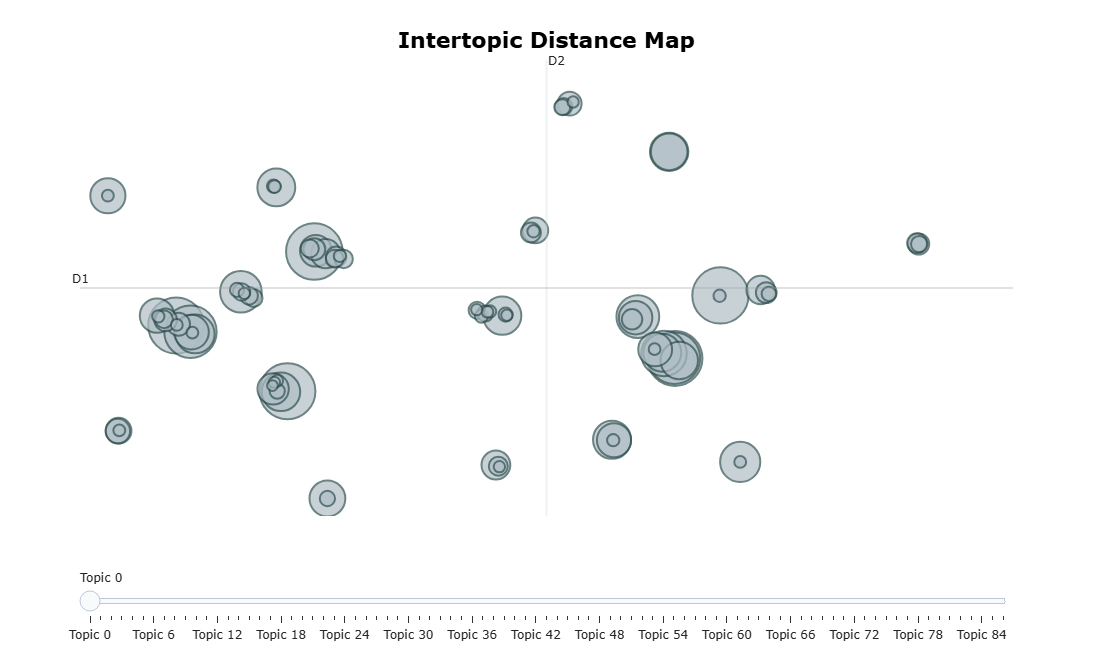

In [13]:
# visualize the topic models of bert topic
topic_model.visualize_topics()

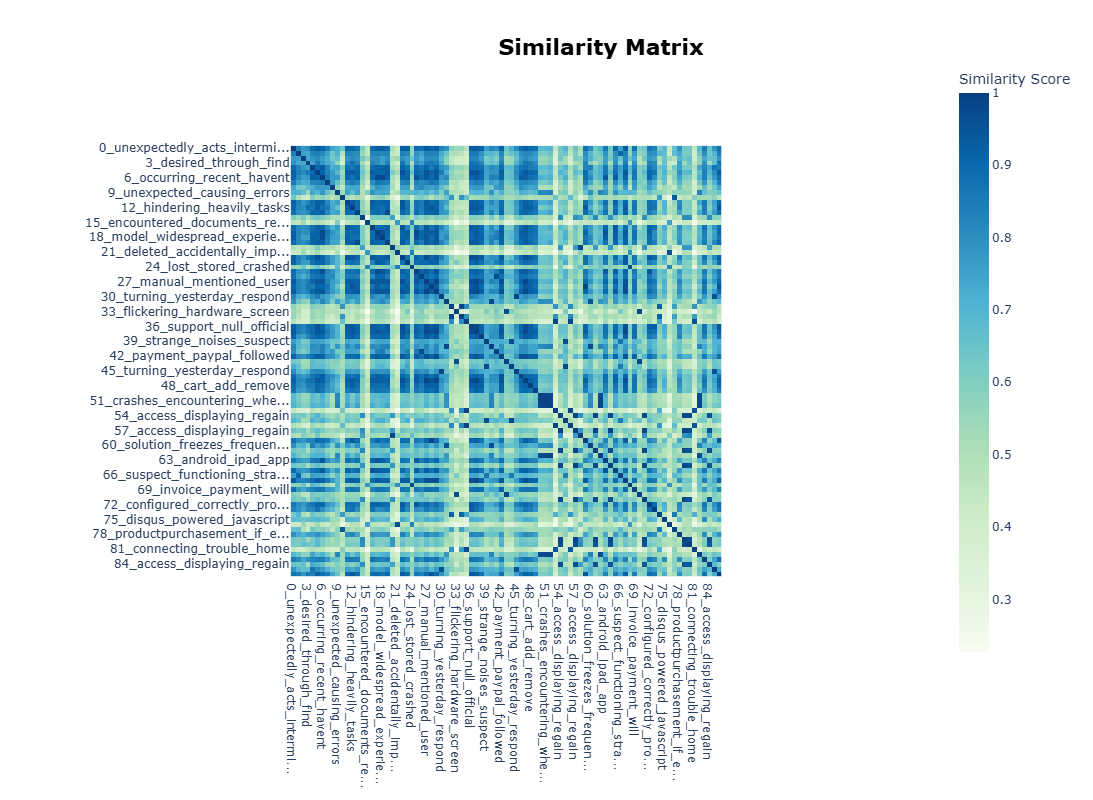

In [14]:
# Heatmap of Topic Similarities
display(topic_model.visualize_heatmap())

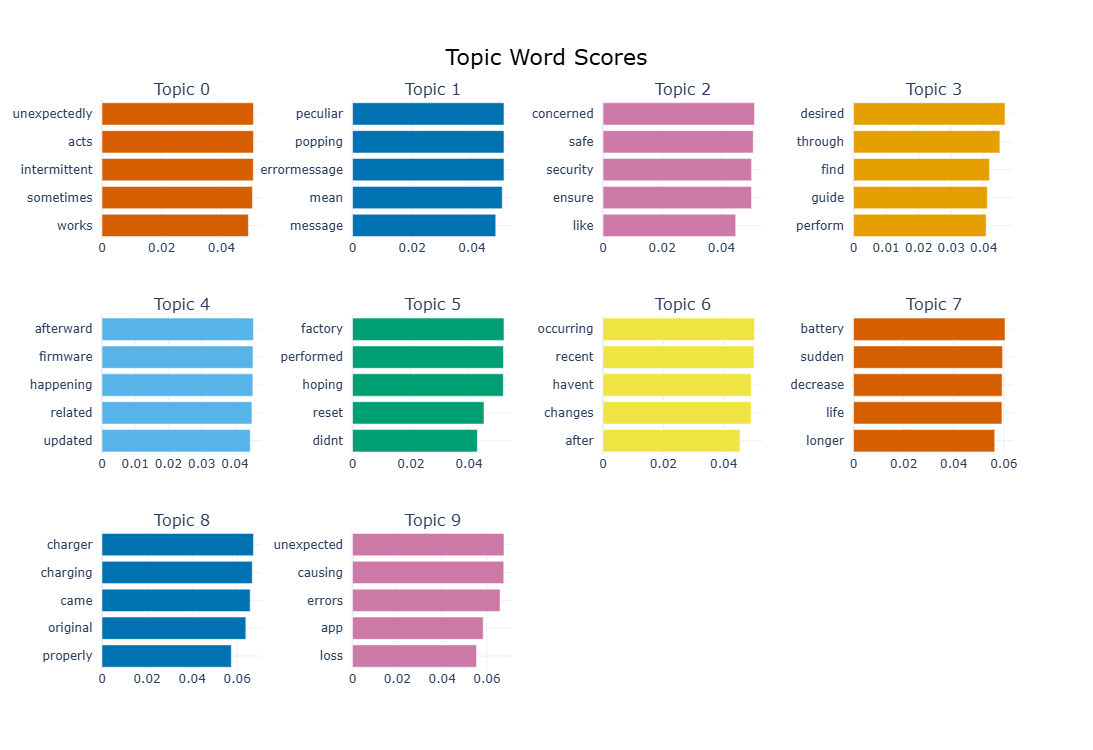

In [15]:
# Distribution of Topic Frequencies (Histogram-style)
display(topic_model.visualize_barchart(top_n_topics=10))

#### LDA TOPIC VISUALIZATION 


BoW LDA | 5 topics


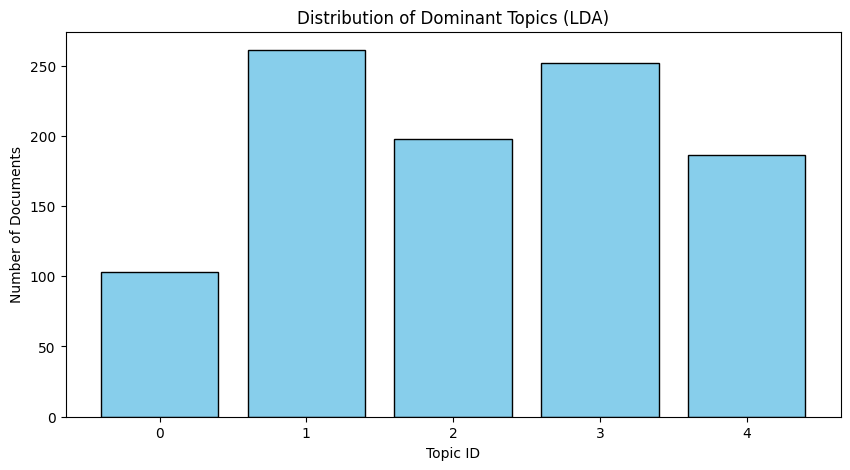


BoW LDA | 6 topics


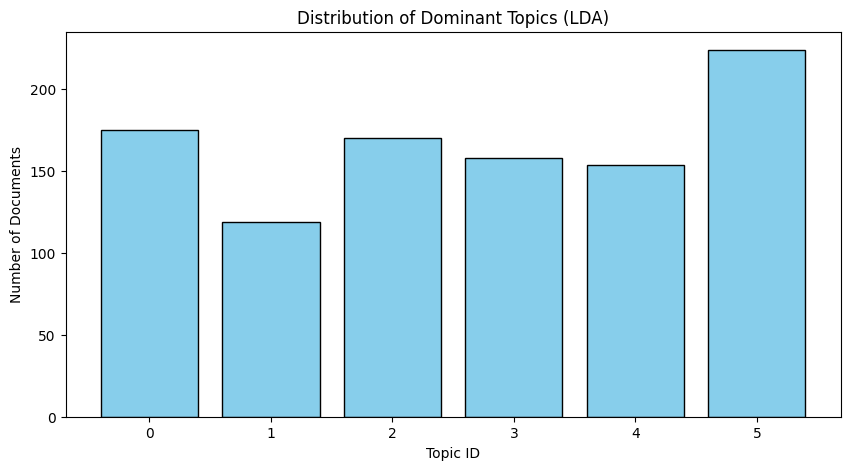


BoW LDA | 7 topics


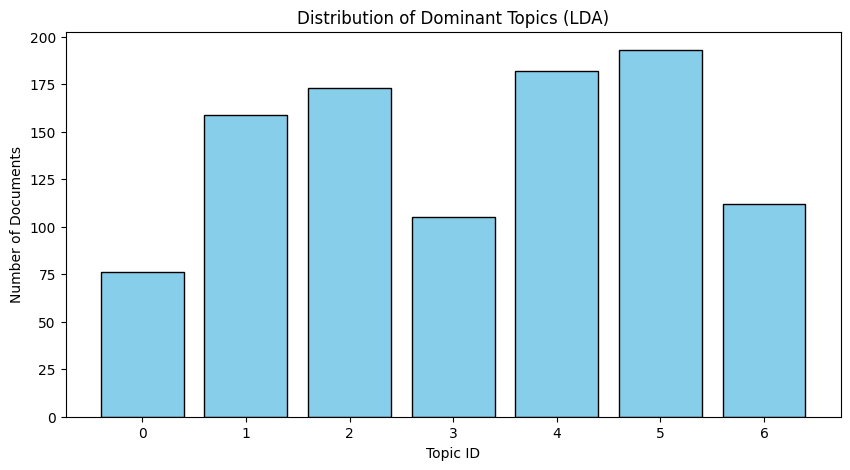


BoW LDA | 8 topics


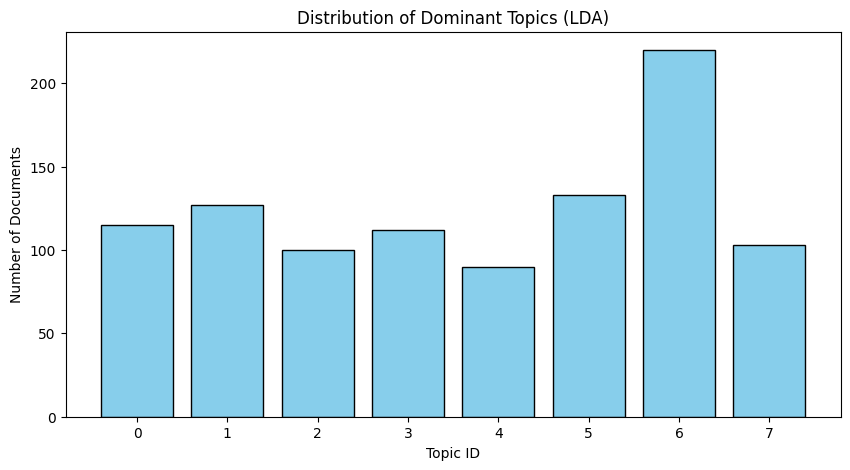


BoW LDA | 9 topics


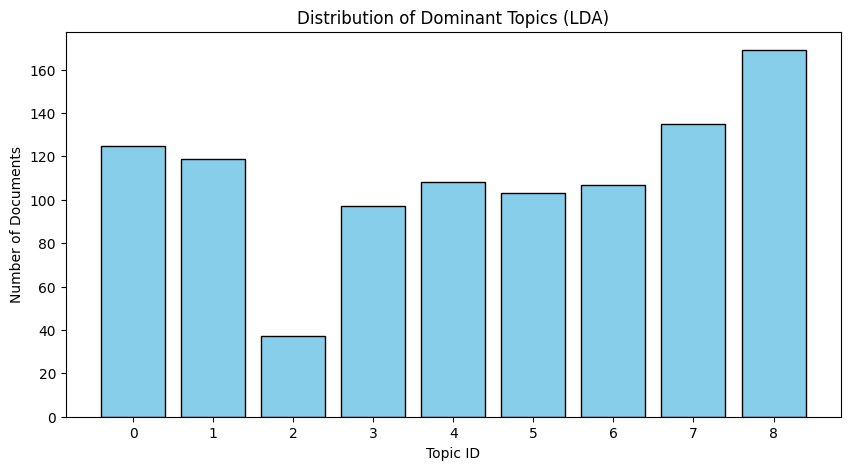


BoW LDA | 10 topics


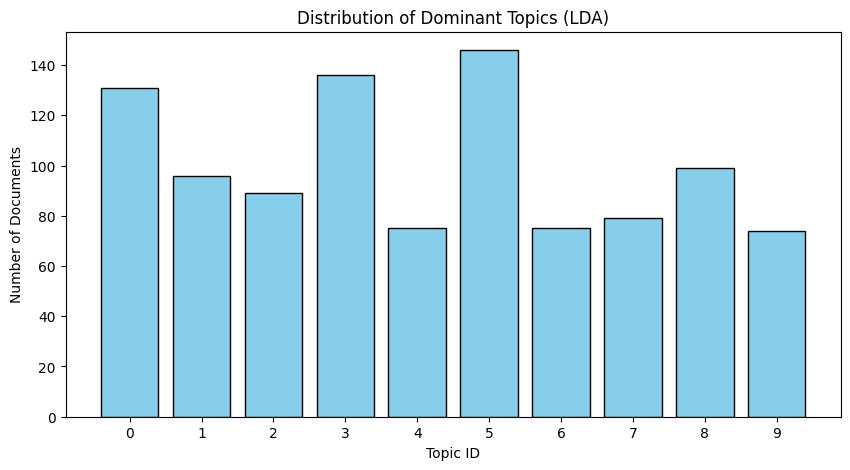

In [16]:
# LDA model with BoW — Histogram (all topic counts 5–10)
for n_topics, (lda_model, _) in lda_dict_bow.items():
    print(f"\nBoW LDA | {n_topics} topics")
    plot_topicModel_histogram(lda_model, trained_bow[:1000])


TF-IDF LDA | 5 topics


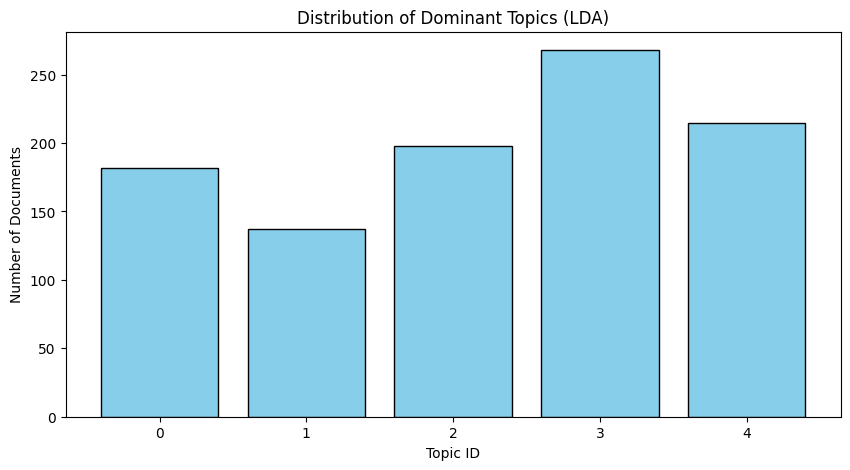


TF-IDF LDA | 6 topics


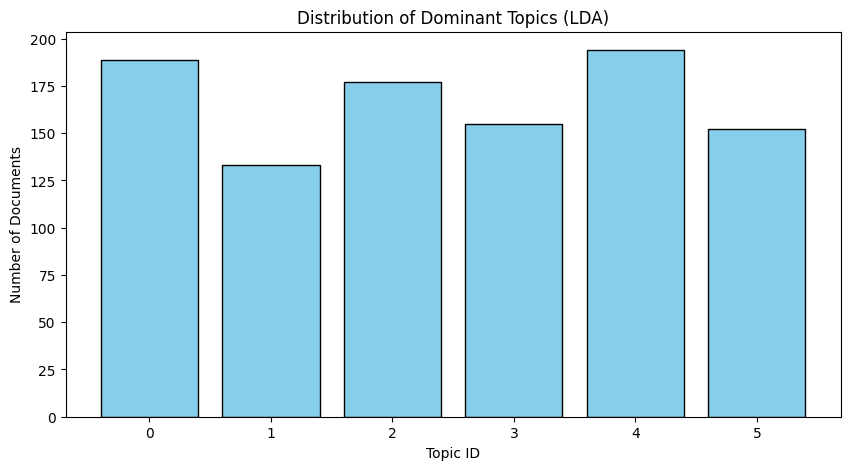


TF-IDF LDA | 7 topics


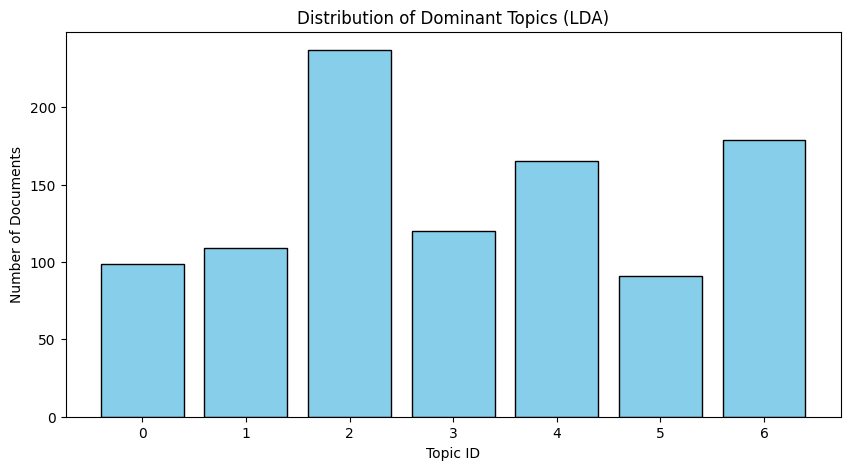


TF-IDF LDA | 8 topics


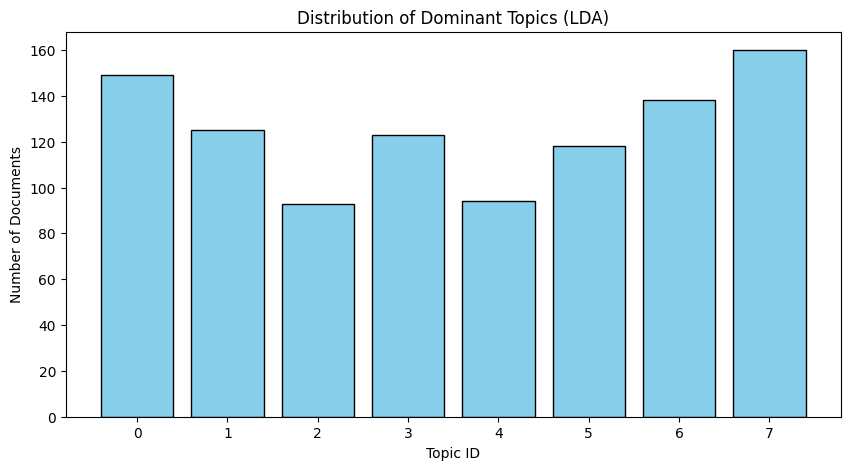


TF-IDF LDA | 9 topics


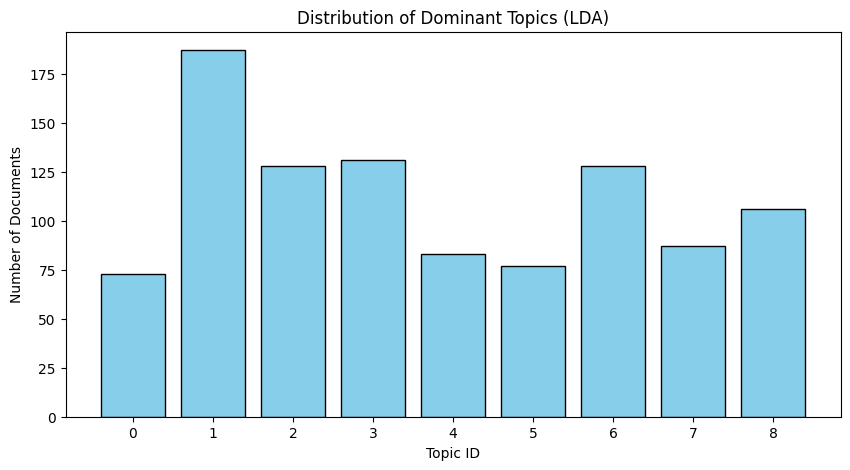


TF-IDF LDA | 10 topics


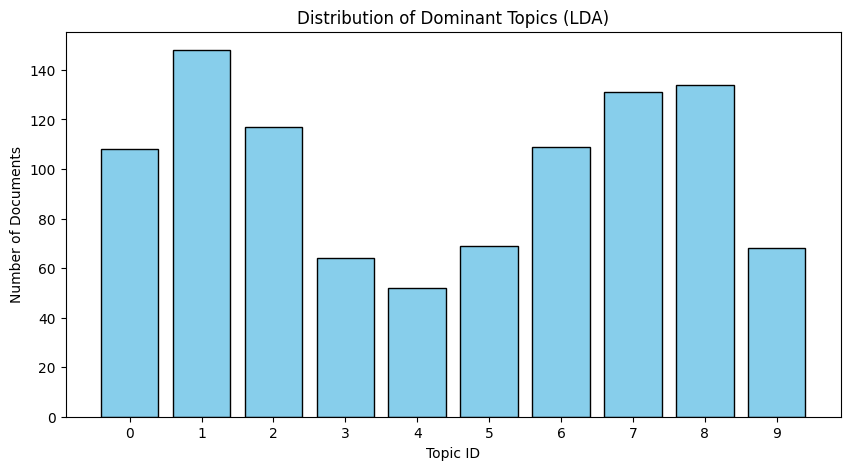

In [17]:
# LDA model with TF-IDF — Histogram (all topic counts 5–10)
for n_topics, (lda_model, _) in lda_dict_tfidf.items():
    print(f"\nTF-IDF LDA | {n_topics} topics")
    plot_topicModel_histogram(lda_model, trained_tfidf[:1000])


BoW LDA | 5 topics


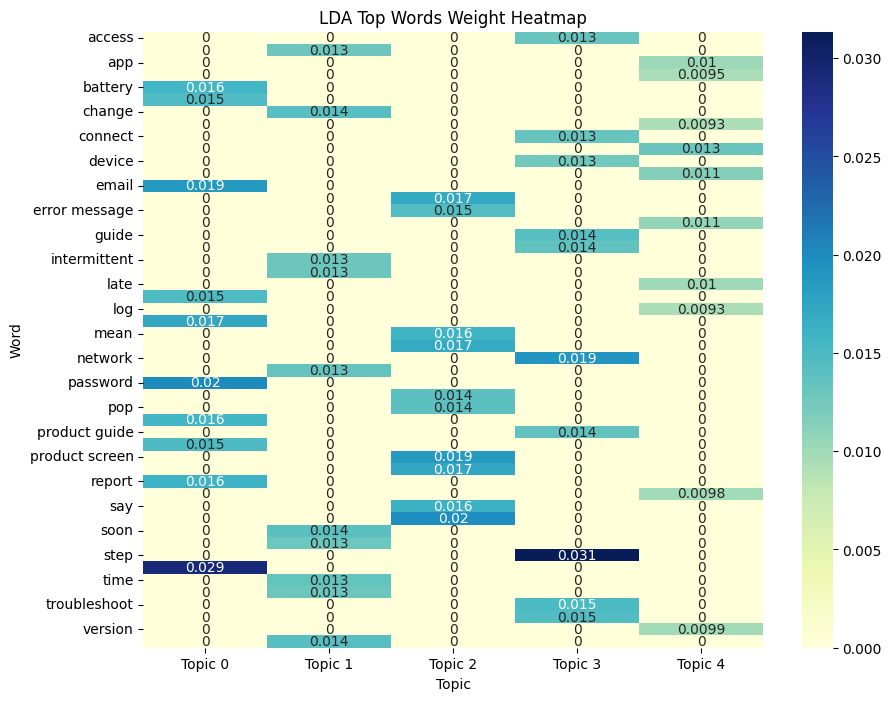


BoW LDA | 6 topics


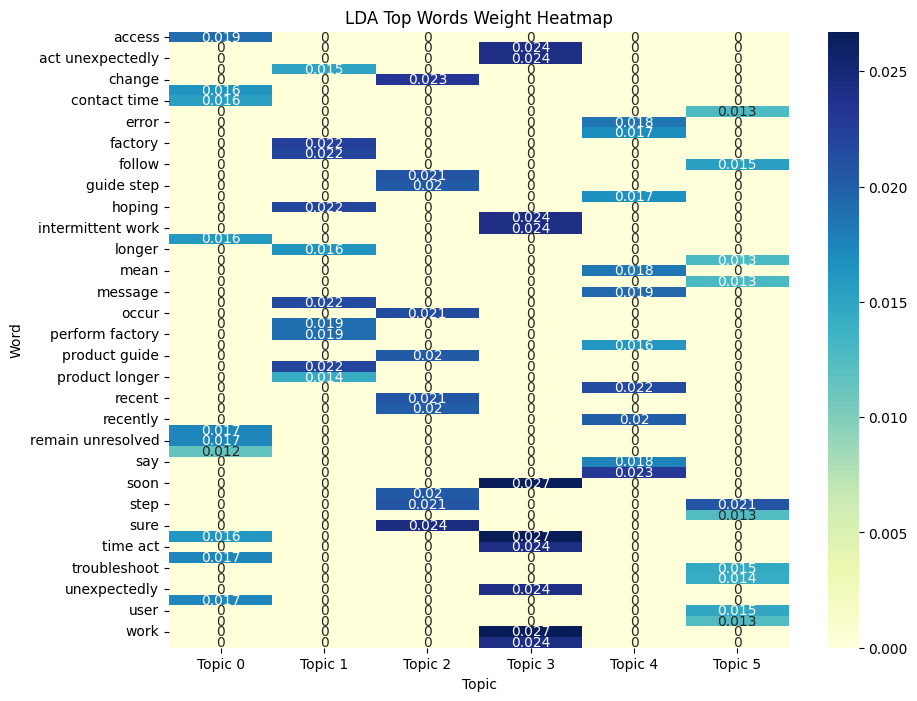


BoW LDA | 7 topics


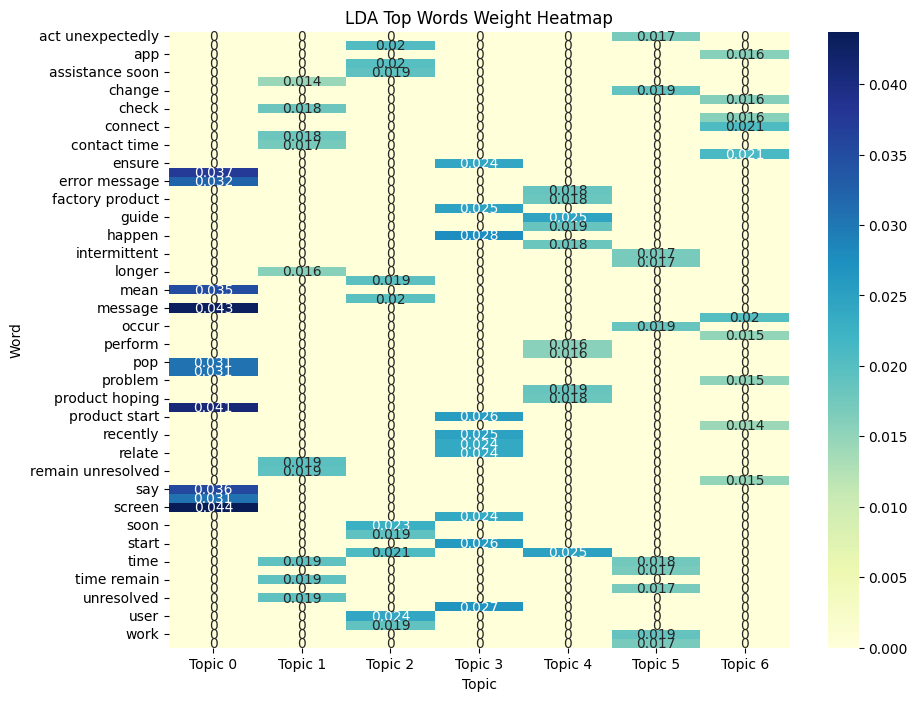


BoW LDA | 8 topics


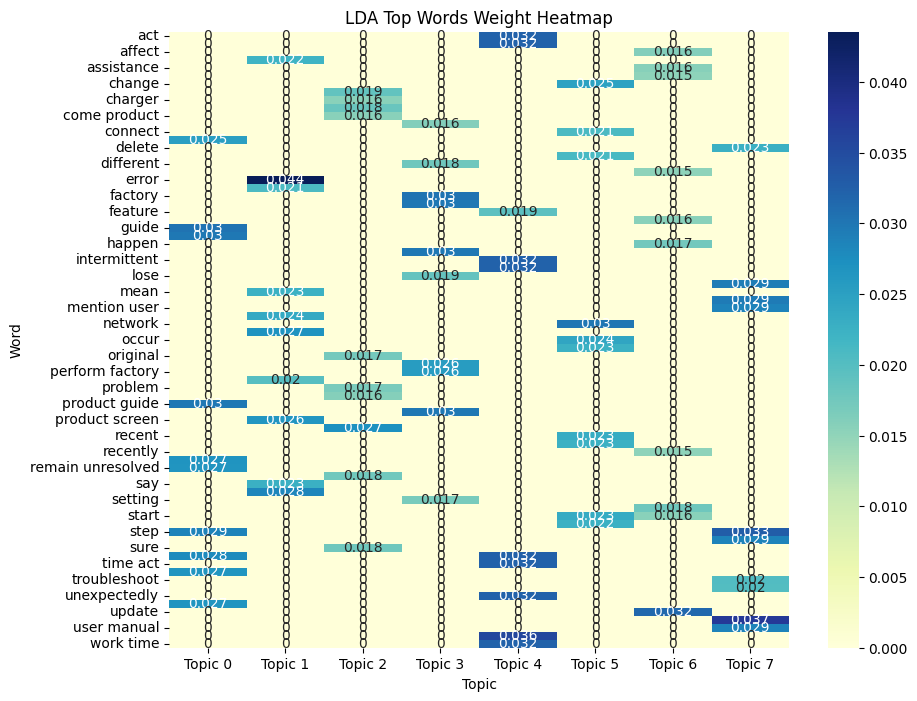


BoW LDA | 9 topics


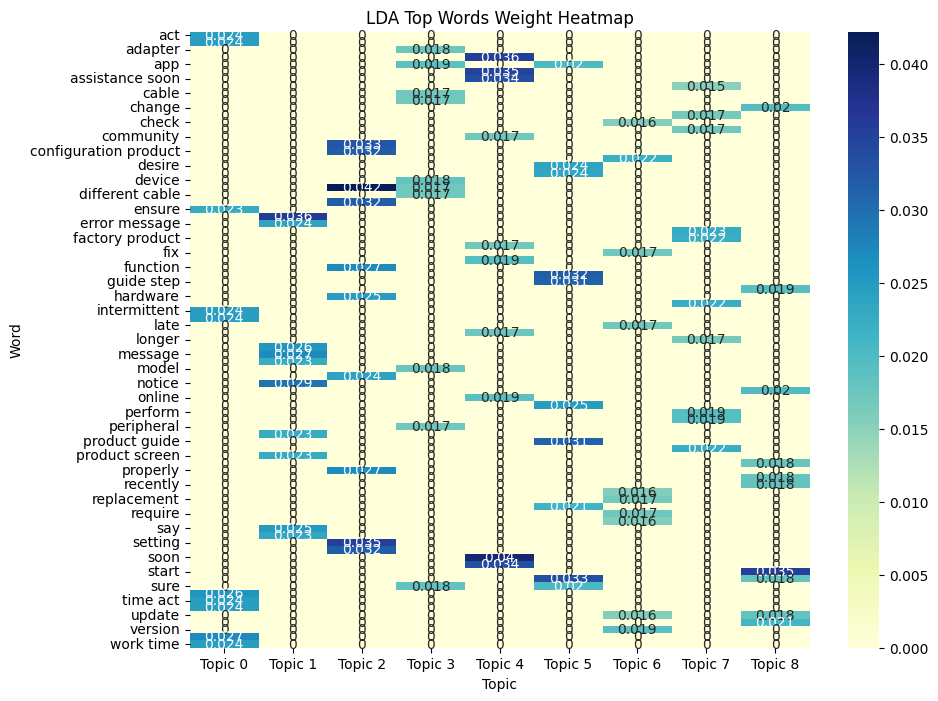


BoW LDA | 10 topics


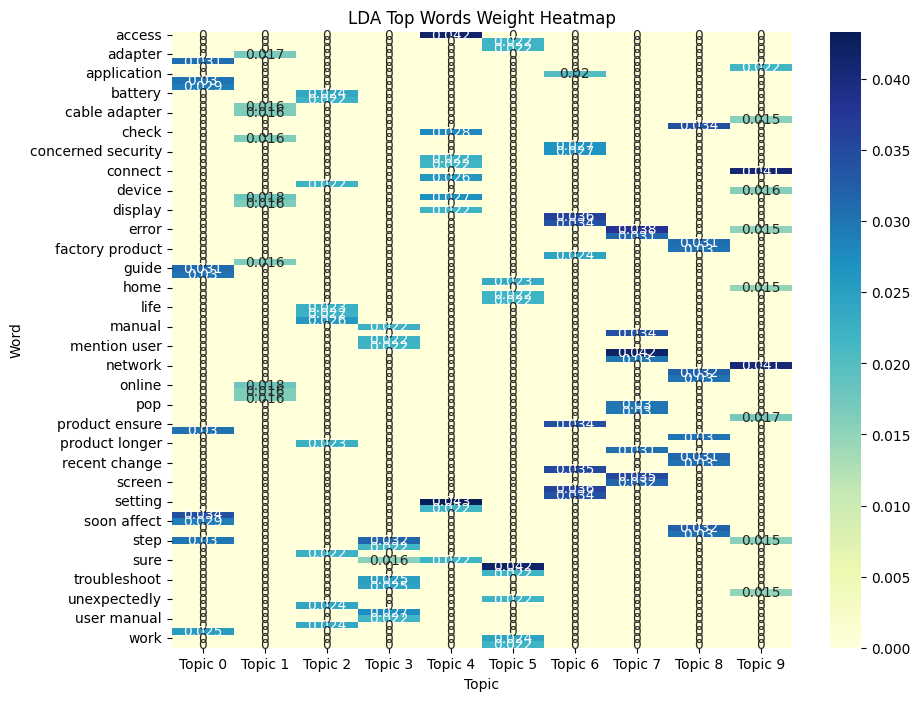

In [18]:
# LDA model with BoW — Heatmap (all topic counts 5–10)
for n_topics, (lda_model, _) in lda_dict_bow.items():
    print(f"\nBoW LDA | {n_topics} topics")
    plot_topicModel_heatmap(lda_model)


TF-IDF LDA | 5 topics


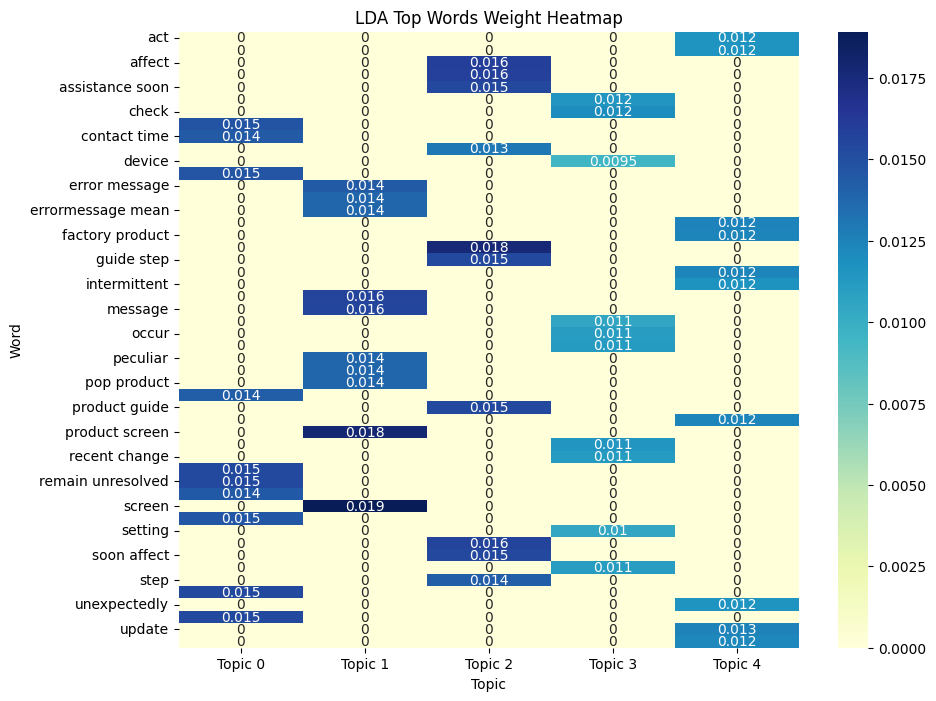


TF-IDF LDA | 6 topics


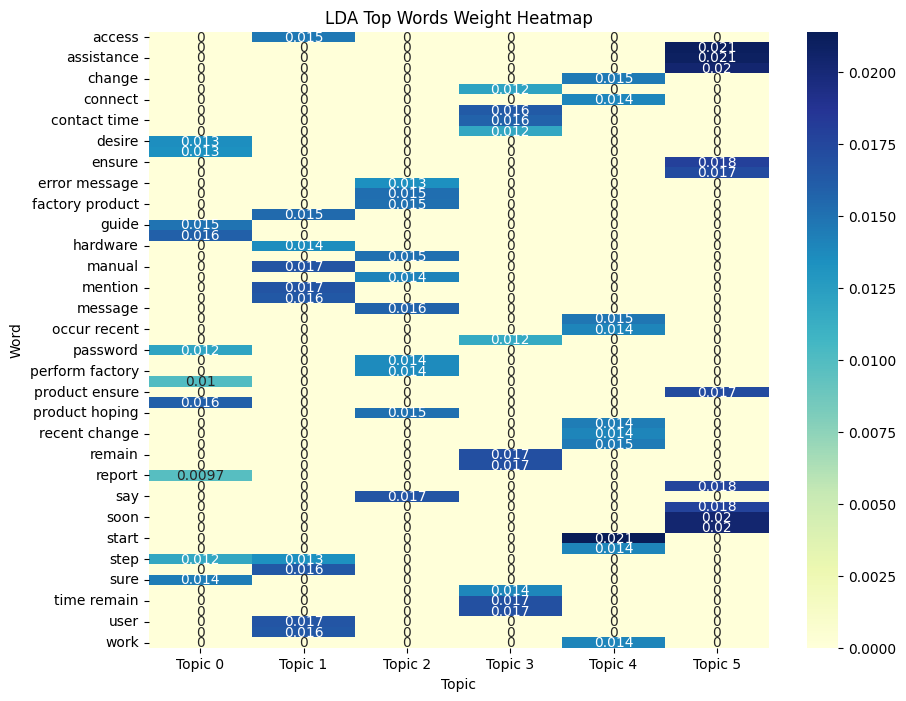


TF-IDF LDA | 7 topics


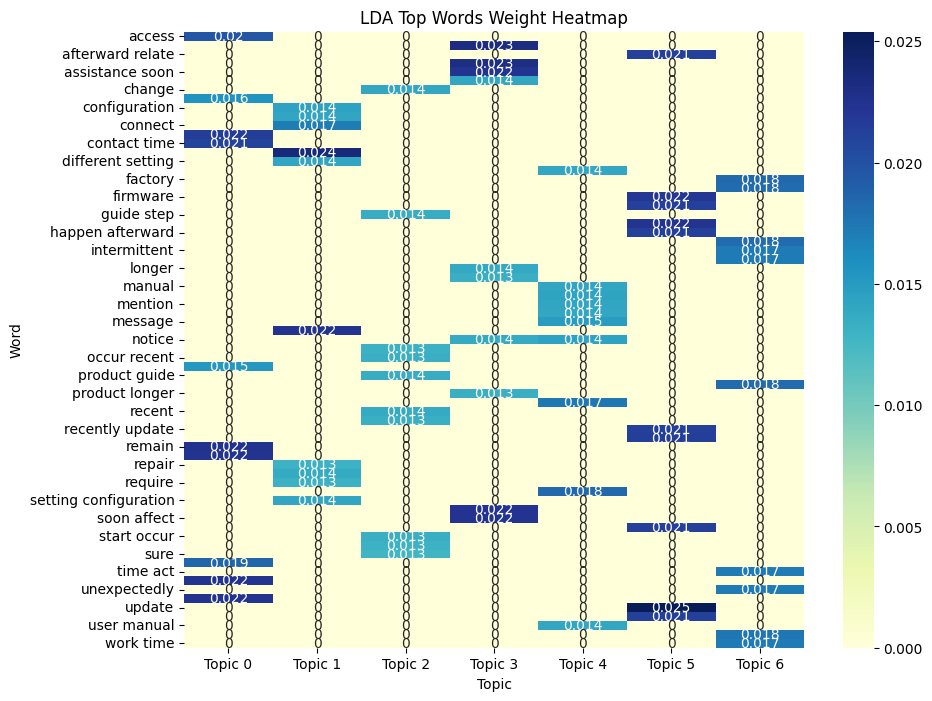


TF-IDF LDA | 8 topics


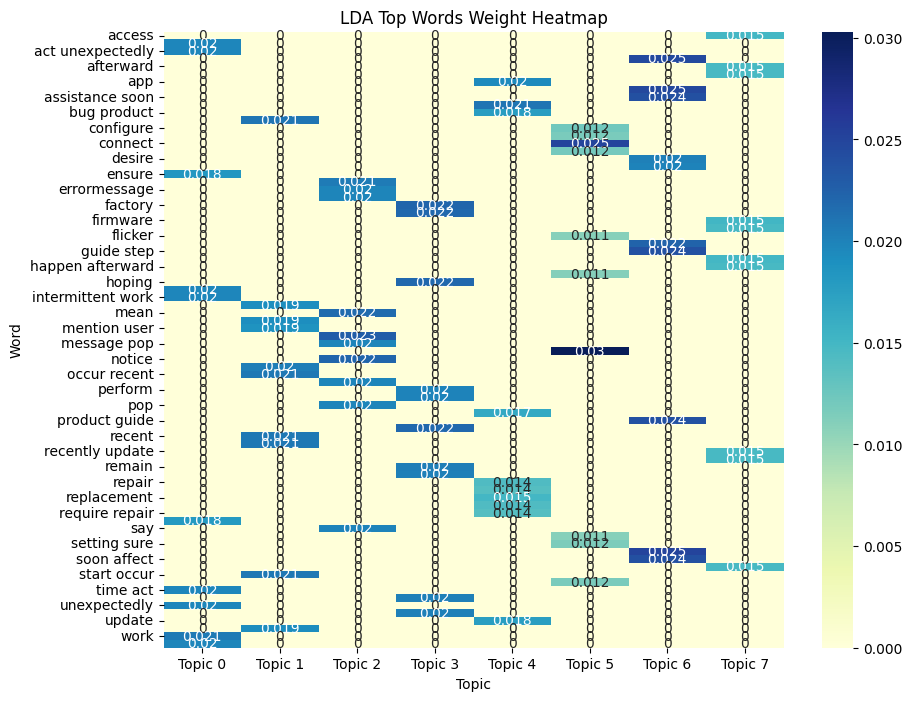


TF-IDF LDA | 9 topics


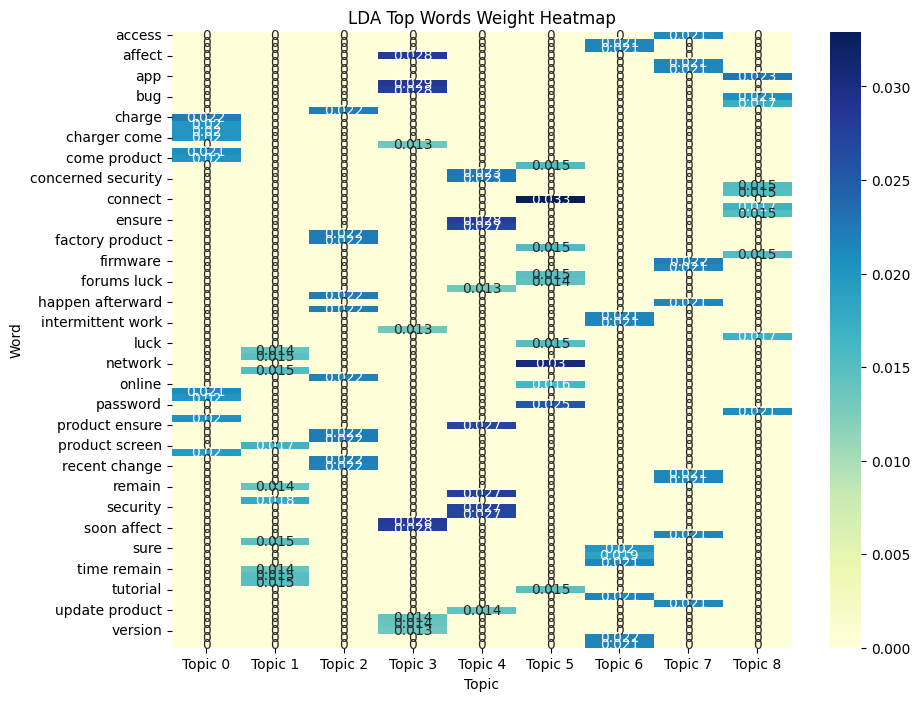


TF-IDF LDA | 10 topics


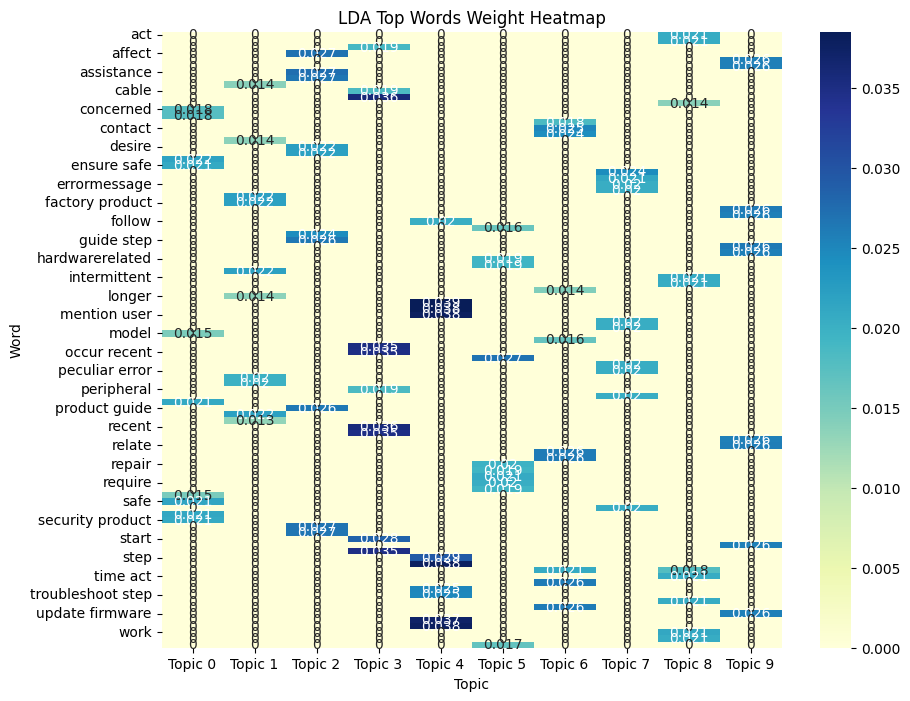

In [19]:
# LDA model with TF-IDF — Heatmap (all topic counts 5–10)
for n_topics, (lda_model, _) in lda_dict_tfidf.items():
    print(f"\nTF-IDF LDA | {n_topics} topics")
    plot_topicModel_heatmap(lda_model)

## TEST MODELS ON TEST DATA

#### BERTOPIC

In [20]:
# Test BERTopic
# For BERTopic, we pass the raw text column from X_test
text_test = X_test['Ticket Description']
test_topics, test_probs = topic_model.transform(text_test.to_list())

print(f"test topic: {test_topics}, test probs: {test_probs}")

test topic: [np.int64(16), np.int64(35), np.int64(2), np.int64(1), np.int64(7), np.int64(15), np.int64(1), np.int64(7), np.int64(52), np.int64(16), np.int64(16), np.int64(15), np.int64(0), np.int64(51), np.int64(38), np.int64(3), np.int64(-1), np.int64(20), np.int64(1), np.int64(32), np.int64(39), np.int64(-1), np.int64(-1), np.int64(61), np.int64(4), np.int64(6), np.int64(5), np.int64(4), np.int64(2), np.int64(20), np.int64(18), np.int64(0), np.int64(6), np.int64(-1), np.int64(-1), np.int64(11), np.int64(-1), np.int64(2), np.int64(-1), np.int64(8), np.int64(37), np.int64(55), np.int64(-1), np.int64(34), np.int64(4), np.int64(1), np.int64(36), np.int64(54), np.int64(5), np.int64(1), np.int64(55), np.int64(9), np.int64(3), np.int64(15), np.int64(8), np.int64(-1), np.int64(30), np.int64(0), np.int64(38), np.int64(8), np.int64(25), np.int64(11), np.int64(-1), np.int64(42), np.int64(14), np.int64(-1), np.int64(25), np.int64(1), np.int64(5), np.int64(36), np.int64(4), np.int64(1), np.int64(

#### EVALUATE ALL LDA MODELS (5–10 topics)

Evaluate every trained model on the held-out test corpus.  
The model with the highest coherence score will be identified as the best one.

#### BEST MODEL SELECTION

Identify the best model from the evaluation results.  
The topic counts sweep 5–10, so the best model reflects both the ticket-type (5) and ticket-subject (9) ground truth.

In [25]:
def evaluate_models(lda_dict, texts, corpus=None, metric='c_v'):
    records = []

    if hasattr(texts, 'tolist'):
        texts = texts.tolist()

    for n_topics, (model, dictionary) in lda_dict.items():
        if isinstance(dictionary, dict):
            print(dictionary)
            gensim_dict = gensim_corpora.Dictionary()
            gensim_dict.token2id = {k: int(v) for k, v in dictionary.items()}
            gensim_dict.id2token = {int(v): k for k, v in dictionary.items()}
            # Required internal attributes gensim expects to exist
            gensim_dict.num_docs = 0
            gensim_dict.num_pos  = 0
            gensim_dict.num_nnz  = 0
        else:
            gensim_dict = dictionary

        cm = CoherenceModel(
            model=model,
            texts=texts if metric != 'u_mass' else None,
            corpus=corpus if metric == 'u_mass' else None,
            dictionary=gensim_dict,
            coherence=metric
        )
        records.append({
            'n_topics': n_topics,
            'coherence_score': cm.get_coherence()
        })
    return pd.DataFrame(records)

# Processing pipeline of test data
test_tokens = preprocess_text(X_test['Ticket Description'])

# BoW and TF-IDF representations
test_bow, test_tfidf = build_all_representations(test_tokens)

# Pass test_tokens as texts, test_bow/test_tfidf as corpus
results_bow   = evaluate_models(lda_dict_bow,   test_tokens, corpus=test_bow)
results_tfidf = evaluate_models(lda_dict_tfidf, test_tokens, corpus=test_tfidf)

print(results_bow)
print(results_tfidf)

# ── Best model selection ─────────────────────────────────────────────────────
# FIX: best_bow_n_topics / best_tfidf_n_topics were never defined;
#      they are needed by the final test validation and save-models cells.
best_bow_idx      = results_bow['coherence_score'].idxmax()
best_bow_n_topics = int(results_bow.loc[best_bow_idx, 'n_topics'])

best_tfidf_idx      = results_tfidf['coherence_score'].idxmax()
best_tfidf_n_topics = int(results_tfidf.loc[best_tfidf_idx, 'n_topics'])

best_bow_model   = lda_dict_bow[best_bow_n_topics][0]
best_tfidf_model = lda_dict_tfidf[best_tfidf_n_topics][0]

print(f"Best BoW   LDA model : {best_bow_n_topics} topics")
print(f"Best TF-IDF LDA model: {best_tfidf_n_topics} topics")

Building BoW... shape: (1694, 5000)
Building TF-IDF... shape: (1694, 1035)
{0: 'ability', 1: 'absolutely', 2: 'accept', 3: 'accept payment', 4: 'accept return', 5: 'access', 6: 'access app', 7: 'access assistance', 8: 'access check', 9: 'access concerned', 10: 'access contact', 11: 'access create', 12: 'access desired', 13: 'access different', 14: 'access enter', 15: 'access follow', 16: 'access intermittent', 17: 'access login', 18: 'access notice', 19: 'access original', 20: 'access perform', 21: 'access product', 22: 'access recently', 23: 'access review', 24: 'access simply', 25: 'access solution', 26: 'access start', 27: 'access worry', 28: 'accessible', 29: 'accessory', 30: 'accidentally', 31: 'accidentally delete', 32: 'accord', 33: 'account', 34: 'act', 35: 'act unexpectedly', 36: 'activate', 37: 'active', 38: 'activity', 39: 'actual', 40: 'actually', 41: 'adapter', 42: 'adapter peripheral', 43: 'add', 44: 'add cart', 45: 'add friend', 46: 'add item', 47: 'add list', 48: 'add n

ValueError: invalid literal for int() with base 10: 'ability'

#### FINAL TEST VALIDATION: 5-TOPIC MODEL

As per the ground truth (5 ticket types), the 5-topic LDA model is used for
the final side-by-side comparison with BERTopic on test documents.

In [ ]:
# Filter bow to model vocabulary
def filter_bow_to_model_vocab(bow_doc, num_terms):
    """Drop any word IDs that exceed the LDA model's trained vocabulary size."""
    return [(wid, cnt) for wid, cnt in bow_doc if wid < num_terms]

In [ ]:
# Use the 5-topic BoW model for final test validation
# (5 topics aligns with the 5 ground-truth ticket types)
selected_lda_model = best_bow_model
num_terms = selected_lda_model.num_terms

# FIX: test_bow_gensim was never defined; build it from the best model's
# vocabulary so each test document is in gensim [(word_id, count)] format.
best_bow_gensim_dict = lda_dict_bow[best_bow_n_topics][1]
if isinstance(best_bow_gensim_dict, dict):
    _g = gensim_corpora.Dictionary()
    _g.token2id = best_bow_gensim_dict
    _g.id2token = {v: k for k, v in best_bow_gensim_dict.items()}
    best_bow_gensim_dict = _g
test_bow_gensim = [best_bow_gensim_dict.doc2bow(doc) for doc in test_tokens.tolist()]

for doc_idx in range(3):
    raw_text   = X_test['Ticket Description'].iloc[doc_idx]
    bert_topic = test_topics[doc_idx]
    prob_array = test_probs[doc_idx]
    bert_prob  = float(prob_array.max()) if hasattr(prob_array, 'max') else float(prob_array)

    print(f"--- Test Document {doc_idx} ---")
    print(f"Description : {raw_text[:150]}...")
    print(f"BERTopic    : Topic {bert_topic} | Confidence: {bert_prob:.4f}")

    # Filter out-of-vocab word IDs before passing to gensim 
    raw_bow = test_bow_gensim[doc_idx]
    current_doc_bow = filter_bow_to_model_vocab(raw_bow, num_terms)

    lda_topics = selected_lda_model.get_document_topics(current_doc_bow)

    if lda_topics:
        lda_ids, lda_scores = zip(*lda_topics)
    else:
        lda_ids, lda_scores = [], []

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    if lda_ids:
        ax.bar(lda_ids, lda_scores,
               color='skyblue', alpha=0.7, label='LDA Topic Distribution')
    ax.axhline(
        y=bert_prob, color='red', linestyle='--', linewidth=2,
        label=f'BERTopic Max Confidence ({bert_prob:.4f})'
    )
    n_topics = selected_lda_model.num_topics
    ax.set_title(f"Document {doc_idx}: LDA ({n_topics} topics) vs BERTopic")
    ax.set_xlabel("Topic ID")
    ax.set_ylabel("Probability / Confidence")
    if lda_ids:
        ax.set_xticks(list(lda_ids))
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print()

## SAVE MODELS AND DATA

Save the best model. 

In [ ]:
# Create the output directory
models_dir = os.path.join(root_path, 'models', 'topic_modelling')
os.makedirs(models_dir, exist_ok=True)
print(f"Saving artefacts to: {models_dir}")

# ── Best LDA BoW model + its gensim dictionary ─────────────────────────────
with open(os.path.join(models_dir, 'lda_best_bow.pkl'), 'wb') as f:
    pickle.dump(best_bow_model, f)
best_bow_dict = lda_dict_bow[best_bow_n_topics][1]         
with open(os.path.join(models_dir, 'lda_best_bow_dict.pkl'), 'wb') as f:
    pickle.dump(best_bow_dict, f)
print(f"Best BoW LDA saved  ({best_bow_n_topics} topics)")

# ── Best LDA TF-IDF model + its gensim dictionary ─────────────────────────
with open(os.path.join(models_dir, 'lda_best_tfidf.pkl'), 'wb') as f:
    pickle.dump(best_tfidf_model, f)
best_tfidf_dict = lda_dict_tfidf[best_tfidf_n_topics][1] 
with open(os.path.join(models_dir, 'lda_best_tfidf_dict.pkl'), 'wb') as f:
    pickle.dump(best_tfidf_dict, f)
print(f"Best TF-IDF LDA saved  ({best_tfidf_n_topics} topics)")

# ── Vectorizers ────────────────────────────────────────────────────────────
with open(os.path.join(models_dir, 'bow_vectorizer.pkl'), 'wb') as f:
    pickle.dump(bow_vectorizer, f)
with open(os.path.join(models_dir, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("Vectorizers saved")

# ── BERTopic model + topics / probs ────────────────────────────────────────
bert_model_path = os.path.join(models_dir, 'bertopic_model')
topic_model.save(bert_model_path)
with open(os.path.join(models_dir, 'bert_train_topics.pkl'), 'wb') as f:
    pickle.dump({'topics': topics, 'probs': probs}, f)
with open(os.path.join(models_dir, 'bert_test_topics.pkl'), 'wb') as f:
    pickle.dump({'test_topics': test_topics, 'test_probs': test_probs}, f)
print("BERTopic model + topics/probs saved")

# ── Evaluation results ─────────────────────────────────────────────────────
with open(os.path.join(models_dir, 'eval_results_bow.pkl'), 'wb') as f:
    pickle.dump(results_bow, f)
with open(os.path.join(models_dir, 'eval_results_tfidf.pkl'), 'wb') as f:
    pickle.dump(results_tfidf, f)
print("Evaluation results saved")

# ── Model registry ────────────────────────────────────────────────────────────
model_registry = {
    'lda_bow': {
        'best_n_topics':  best_bow_n_topics,
        'model_path':     os.path.join(models_dir, 'lda_best_bow.pkl'),
        'dict_path':      os.path.join(models_dir, 'lda_best_bow_dict.pkl'),
        'vectorizer_path': os.path.join(models_dir, 'bow_vectorizer.pkl'),
        'eval_path':      os.path.join(models_dir, 'eval_results_bow.pkl'),
    },
    'lda_tfidf': {
        'best_n_topics':  best_tfidf_n_topics,
        'model_path':     os.path.join(models_dir, 'lda_best_tfidf.pkl'),
        'dict_path':      os.path.join(models_dir, 'lda_best_tfidf_dict.pkl'),
        'vectorizer_path': os.path.join(models_dir, 'tfidf_vectorizer.pkl'),
        'eval_path':      os.path.join(models_dir, 'eval_results_tfidf.pkl'),
    },
    'bertopic': {
        'model_path':        bert_model_path,
        'train_topics_path': os.path.join(models_dir, 'bert_train_topics.pkl'),
        'test_topics_path':  os.path.join(models_dir, 'bert_test_topics.pkl'),
    },
    # ── Eval results: keyed the way Evaluation.ipynb expects ─────────────────
    'eval_results': {
        'bow':   os.path.join(models_dir, 'eval_results_bow.pkl'),
        'tfidf': os.path.join(models_dir, 'eval_results_tfidf.pkl'),
    },
}
with open(os.path.join(models_dir, 'model_registry.pkl'), 'wb') as f:
    pickle.dump(model_registry, f)

print("\nAll artefacts saved successfully.")
print(f"Saved to: {models_dir}")